[*********************100%***********************]  16 of 16 completed



==== Top 5 Performing Indices in Last 3 Years ====
Ticker
^NDX      1.234599
^N225     0.823707
^GSPC     0.746451
^KS11     0.720678
^GDAXI    0.684862
dtype: float64

========== Tangency Portfolio (Max Sharpe) ==========
^NDX: 0.6651
^N225: 0.0000
^GSPC: 0.0000
^KS11: 0.0000
^GDAXI: 0.3349

Return: 0.2603
Volatility: 0.1631
Sharpe Ratio: 1.3506

========== Minimum Variance Portfolio ==========
^NDX: 0.0000
^N225: 0.0353
^GSPC: 0.4082
^KS11: 0.2064
^GDAXI: 0.3501

Return: 0.168
Volatility: 0.1181


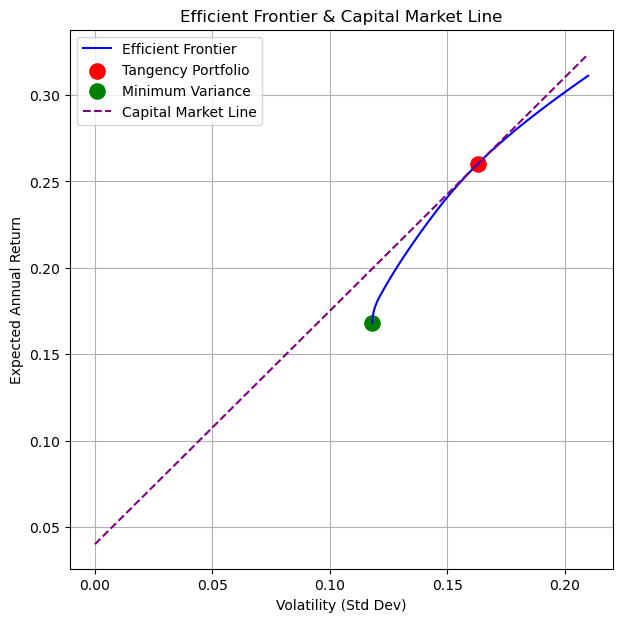

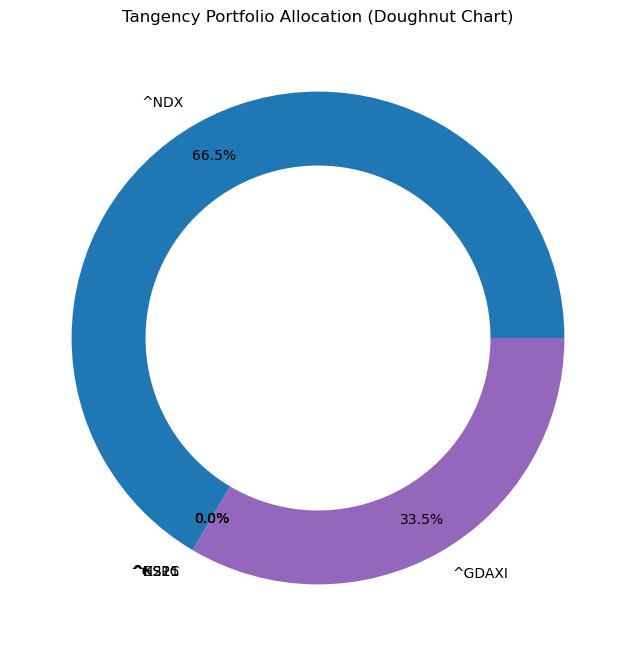

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from scipy.optimize import minimize
import matplotlib.pyplot as plt

all_indices = {
    "S&P 500": "^GSPC",
    "NASDAQ 100": "^NDX",
    "FTSE 100": "^FTSE",
    "DAX (Germany)": "^GDAXI",
    "CAC 40 (France)": "^FCHI",
    "Swiss SMI": "^SSMI",
    "Nikkei 225": "^N225",
    "Shanghai Composite": "000001.SS",
    "CSI 300": "000300.SS",
    "Hang Seng": "^HSI",
    "India Nifty 50": "^NSEI",
    "India Sensex": "^BSESN",
    "Australia ASX200": "^AXJO",
    "KOSPI (Korea)": "^KS11",
    "Canada TSX": "^GSPTSE",
    "Brazil Bovespa": "^BVSP",
}

end_date = datetime.today()
start_date = end_date - timedelta(days=3 * 365)

tickers = list(all_indices.values())

prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

total_returns = (prices.iloc[-1] / prices.iloc[0] - 1)
top5 = total_returns.sort_values(ascending=False).head(5)

selected_tickers = top5.index.tolist()
print("\n==== Top 5 Performing Indices in Last 3 Years ====")
print(top5)


log_returns = np.log(prices[selected_tickers] / prices[selected_tickers].shift(1)).dropna()

mu = log_returns.mean().values * 252          
cov = log_returns.cov().values * 252           
n = len(selected_tickers)

risk_free_rate = 0.04

def port_return(w):
    return w @ mu

def port_vol(w):
    return np.sqrt(w @ cov @ w)

def sharpe(w):
    return (port_return(w) - risk_free_rate) / port_vol(w)

def neg_sharpe(w):
    return -sharpe(w)

bounds = [(0.0, 1)] * n
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
w0 = np.ones(n) / n

tan_res = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=constraints)
w_tan = tan_res.x

tan_ret = port_return(w_tan)
tan_vol = port_vol(w_tan)
tan_sharpe = sharpe(w_tan)

def port_var(w):
    return w @ cov @ w

min_var_res = minimize(port_var, w0, method='SLSQP', bounds=bounds, constraints=constraints)
w_minvar = min_var_res.x

minvar_ret = port_return(w_minvar)
minvar_vol = port_vol(w_minvar)

target_returns = np.linspace(minvar_ret, mu.max(), 80)

def frontier_vol(target):
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: port_return(w) - target},
    ]
    res = minimize(port_vol, w0, method='SLSQP', bounds=bounds, constraints=cons)
    return res.fun

frontier_vols = np.array([frontier_vol(r) for r in target_returns])

cml_x = np.linspace(0, frontier_vols.max(), 100)
cml_y = risk_free_rate + tan_sharpe * cml_x

print("\n========== Tangency Portfolio (Max Sharpe) ==========")
for t, w in zip(selected_tickers, w_tan):
    print(f"{t}: {w:.4f}")

print("\nReturn:", round(tan_ret, 4))
print("Volatility:", round(tan_vol, 4))
print("Sharpe Ratio:", round(tan_sharpe, 4))

print("\n========== Minimum Variance Portfolio ==========")
for t, w in zip(selected_tickers, w_minvar):
    print(f"{t}: {w:.4f}")

print("\nReturn:", round(minvar_ret, 4))
print("Volatility:", round(minvar_vol, 4))

plt.figure(figsize=(7,7))
plt.plot(frontier_vols, target_returns, label="Efficient Frontier", color="blue")

plt.scatter(tan_vol, tan_ret, color="red", s=120, label="Tangency Portfolio")
plt.scatter(minvar_vol, minvar_ret, color="green", s=120, label="Minimum Variance")

plt.plot(cml_x, cml_y, color="purple", linestyle="--", label="Capital Market Line")

plt.xlabel("Volatility (Std Dev)")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier & Capital Market Line")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,8))

plt.pie(w_tan, labels=selected_tickers, autopct='%1.1f%%', pctdistance=0.85)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Tangency Portfolio Allocation (Doughnut Chart)")
plt.show()